# PIHT experiment results

This notebook contains the PIHT-only reporting workflow for the standard result files. It validates the result metadata, compares the different dataset setups using their own candidate `K` grids, summarizes test performance, analyzes feature inclusion across horizons, and creates the figures.

In [1]:
# Configuration
SAVE_PLOTS = True
RESULT_GLOB = "*_p*_i*_h*_piht.json"
TOP_FEATURES = 8
DATASET_LABELS = {
    "bdap": "FullBDAP",
    "bdap-anticipazioni": "FullBDAP + Treasury advances",
    "readybdap-anticipazioni": "ReadyBDAP + Treasury advances",
    "indicatori": "Indicators",
    "indicatori-anticipazioni": "Indicators + Treasury advances",
    "bdap-indicatori-anticipazioni": "FullBDAP + Indicators + Treasury advances",
}
METRIC_LABELS = {
    "roc_auc": "ROC AUC",
    "pr_auc_trapezoid": "PR AUC",
    "average_precision": "Average Precision",
    "precision": "Precision",
    "recall": "Recall",
}
import json
import os
import tempfile
import textwrap
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from piht_classification.feature_labels import display_feature_name as catalogue_feature_name

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "piht-matplotlib"))
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Ellipse

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "notebook_plots"
if SAVE_PLOTS:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def finish_plot(figure, filename):
    if SAVE_PLOTS:
        output = PLOTS_DIR / filename
        figure.savefig(output, dpi=180, bbox_inches="tight")
        print(f"Saved {output}")
    plt.show()

def experiment_id(metadata):
    feature_slug = metadata["features"].replace("-", "_")
    return (
        f"{feature_slug}_p{metadata['period']}_i{metadata['input_depth']}"
        f"_h{metadata['target_depth']}"
    )

def dataset_label(metadata):
    raw_name = metadata["features"]
    return DATASET_LABELS.get(raw_name, raw_name.replace("-", " + "))

def setup_label(metadata):
    return f"Period {metadata['period']} - {dataset_label(metadata)}"

def configuration_label(metadata):
    return (
        f"{setup_label(metadata)} - input {metadata['input_depth']} year(s)"
        f" - target {metadata['target_depth']} year(s)"
    )

def display_feature_name(feature, input_depth):
    return catalogue_feature_name(feature)

## Load and validate result files

Change `RESULT_GLOB` above to inspect a narrower subset. The default matches the standard `<dataset>_p<period>_i<input-depth>_h<target-depth>_piht.json` names. The filename is checked against the metadata stored in each file.

In [2]:
def load_result(path):
    result = json.loads(path.read_text(encoding="utf-8"))
    if result.get("protocol") != "piht_80_20_training_selection_per_s_v2":
        raise ValueError(f"{path.name}: old or incompatible experiment protocol")
    repetitions = result.get("repetitions", [])
    if len(repetitions) != result.get("repeats"):
        raise ValueError(
            f"{path.name}: declares {result.get('repeats')} repetitions "
            f"but contains {len(repetitions)}"
        )
    seeds = [repetition["seed"] for repetition in repetitions]
    if len(seeds) != len(set(seeds)):
        raise ValueError(f"{path.name}: repetition seeds are not unique")
    if any("piht" not in repetition for repetition in repetitions):
        raise ValueError(f"{path.name}: a repetition has no PIHT result")
    return result

result_files = sorted(RESULTS_DIR.glob(RESULT_GLOB))
if not result_files:
    raise FileNotFoundError(f"No files matching {RESULT_GLOB!r} in {RESULTS_DIR}")
results = {}
for path in result_files:
    result = load_result(path)
    metadata = result.get("dataset", {})
    experiment = experiment_id(metadata)
    expected_filename = f"{experiment}_piht.json"
    if path.name != expected_filename:
        raise ValueError(
            f"{path.name}: expected standard filename {expected_filename!r} "
            "from its dataset metadata"
        )
    if experiment in results:
        raise ValueError(f"Duplicate experiment {experiment!r}")
    results[experiment] = result

catalog_rows = []
for experiment, result in results.items():
    metadata = result.get("dataset", {})
    catalog_rows.append({
        "experiment": experiment,
        "dataset": metadata.get("features"),
        "dataset_label": dataset_label(metadata),
        "dataset_setup": setup_label(metadata),
        "period": metadata.get("period"),
        "input_depth": metadata.get("input_depth"),
        "target_depth": metadata.get("target_depth"),
        "observations": result["shape"][0],
        "flat_features": result["shape"][1],
        "repeats": result["repeats"],
        "iterations": result["iterations"],
        "candidate_k": tuple(result["k_values"]),
        "n_candidate_k": len(result["k_values"]),
        "batch_size_initial": result.get("batch_size_initial", 64),
        "batch_sampling": result.get("batch_sampling", "uniform"),
        "min_positive_fraction": result.get("min_positive_fraction", 0.0),
        "piht_only_file": result.get("include_baselines") is False,
    })
catalog = (
    pd.DataFrame(catalog_rows)
    .sort_values(["period", "dataset_label", "target_depth"])
    .set_index("experiment")
)
for period, period_catalog in catalog.groupby("period", sort=True):
    print(f"Period {period} configurations")
    display(period_catalog)

Period 1 configurations
Period 2 configurations


,dataset,dataset_label,dataset_setup,period,input_depth,target_depth,observations,flat_features,repeats,iterations,candidate_k,n_candidate_k,batch_size_initial,batch_sampling,min_positive_fraction,piht_only_file
experiment,,,,,,,,,,,,,,,,
bdap_p1_i1_h1,bdap,FullBDAP,Period 1 - FullBDAP,1,1,1,54411,36,1,10000,"(5, 10, 15, 20, 25, 30, 35, 36)",8,256,stratified,0.1,True
bdap_p1_i1_h2,bdap,FullBDAP,Period 1 - FullBDAP,1,1,2,54411,36,1,10000,"(5, 10, 15, 20, 25, 30, 35, 36)",8,256,stratified,0.1,True
bdap_p1_i1_h3,bdap,FullBDAP,Period 1 - FullBDAP,1,1,3,54411,36,1,10000,"(5, 10, 15, 20, 25, 30, 35, 36)",8,256,stratified,0.1,True
bdap_anticipazioni_p1_i1_h1,bdap-anticipazioni,FullBDAP + Treasury advances,Period 1 - FullBDAP + Treasury advances,1,1,1,54411,41,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 41)",9,256,stratified,0.1,True
bdap_anticipazioni_p1_i1_h2,bdap-anticipazioni,FullBDAP + Treasury advances,Period 1 - FullBDAP + Treasury advances,1,1,2,54411,41,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 41)",9,256,stratified,0.1,True
bdap_anticipazioni_p1_i1_h3,bdap-anticipazioni,FullBDAP + Treasury advances,Period 1 - FullBDAP + Treasury advances,1,1,3,54411,41,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 41)",9,256,stratified,0.1,True
readybdap_anticipazioni_p1_i1_h1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,Period 1 - ReadyBDAP + Treasury advances,1,1,1,54411,21,1,10000,"(3, 5, 8, 10, 12, 15, 18, 21)",8,256,stratified,0.1,True
readybdap_anticipazioni_p1_i1_h2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,Period 1 - ReadyBDAP + Treasury advances,1,1,2,54411,21,1,10000,"(3, 5, 8, 10, 12, 15, 18, 21)",8,256,stratified,0.1,True
readybdap_anticipazioni_p1_i1_h3,readybdap-anticipazioni,ReadyBDAP + Treasury advances,Period 1 - ReadyBDAP + Treasury advances,1,1,3,54411,21,1,10000,"(3, 5, 8, 10, 12, 15, 18, 21)",8,256,stratified,0.1,True


,dataset,dataset_label,dataset_setup,period,input_depth,target_depth,observations,flat_features,repeats,iterations,candidate_k,n_candidate_k,batch_size_initial,batch_sampling,min_positive_fraction,piht_only_file
experiment,,,,,,,,,,,,,,,,
bdap_p2_i1_h1,bdap,FullBDAP,Period 2 - FullBDAP,2,1,1,62184,48,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 48)",10,256,stratified,0.1,True
bdap_p2_i1_h2,bdap,FullBDAP,Period 2 - FullBDAP,2,1,2,54411,48,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 48)",10,256,stratified,0.1,True
bdap_p2_i1_h3,bdap,FullBDAP,Period 2 - FullBDAP,2,1,3,46638,48,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 48)",10,256,stratified,0.1,True
bdap_indicatori_anticipazioni_p2_i1_h1,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,Period 2 - FullBDAP + Indicators + Treasury ad...,2,1,1,62184,63,1,10000,"(5, 10, 15, 20, 30, 40, 50, 60, 63)",9,256,stratified,0.1,True
bdap_indicatori_anticipazioni_p2_i1_h2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,Period 2 - FullBDAP + Indicators + Treasury ad...,2,1,2,54411,63,1,10000,"(5, 10, 15, 20, 30, 40, 50, 60, 63)",9,256,stratified,0.1,True
bdap_indicatori_anticipazioni_p2_i1_h3,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,Period 2 - FullBDAP + Indicators + Treasury ad...,2,1,3,46638,63,1,10000,"(5, 10, 15, 20, 30, 40, 50, 60, 63)",9,256,stratified,0.1,True
bdap_anticipazioni_p2_i1_h1,bdap-anticipazioni,FullBDAP + Treasury advances,Period 2 - FullBDAP + Treasury advances,2,1,1,62184,53,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53)",11,256,stratified,0.1,True
bdap_anticipazioni_p2_i1_h2,bdap-anticipazioni,FullBDAP + Treasury advances,Period 2 - FullBDAP + Treasury advances,2,1,2,54411,53,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53)",11,256,stratified,0.1,True
bdap_anticipazioni_p2_i1_h3,bdap-anticipazioni,FullBDAP + Treasury advances,Period 2 - FullBDAP + Treasury advances,2,1,3,46638,53,1,10000,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53)",11,256,stratified,0.1,True


## PIHT test results

The summary tables use only the training-selected PIHT model from each repetition. Diagnostic plots also represent every candidate sparsity value as a held-out point; these candidate test results do not enter model selection. Average precision is the primary rare-event metric. Trapezoidal PR-AUC is retained for reporting compatibility.

In [3]:
metric_rows = []
candidate_metric_rows = []
for experiment, result in results.items():
    metadata = result.get("dataset", {})
    for repetition in result["repetitions"]:
        piht = repetition["piht"]
        for candidate in repetition["k_selection"]:
            test = candidate["test_metrics"]
            candidate_metric_rows.append({
                "experiment": experiment,
                "dataset_label": dataset_label(metadata),
                "period": metadata.get("period"),
                "input_depth": metadata.get("input_depth"),
                "target_depth": metadata.get("target_depth"),
                "seed": repetition["seed"],
                "s": candidate["k"],
                "support_size": candidate["support_size"],
                **{name: test[name] for name in (
                    "average_precision", "pr_auc_trapezoid", "roc_auc",
                    "precision", "recall", "f1", "threshold",
                )},
            })
        candidate_fit_seconds = [
            candidate.get("fit_seconds", np.nan)
            for candidate in repetition["k_selection"]
        ]
        metric_rows.append({
            "experiment": experiment,
            "configuration": configuration_label(metadata),
            "dataset": metadata.get("features"),
            "dataset_label": dataset_label(metadata),
            "dataset_setup": setup_label(metadata),
            "period": metadata.get("period"),
            "input_depth": metadata.get("input_depth"),
            "target_depth": metadata.get("target_depth"),
            "candidate_k": tuple(result["k_values"]),
            "batch_size_initial": result.get("batch_size_initial", 64),
            "batch_sampling": result.get("batch_sampling", "uniform"),
            "min_positive_fraction": result.get("min_positive_fraction", 0.0),
            "seed": repetition["seed"],
            "selected_k": piht["selected_k"],
            "support_size": piht["support_size"],
            "average_precision": piht["average_precision"],
            "pr_auc_trapezoid": piht["pr_auc_trapezoid"],
            "roc_auc": piht["roc_auc"],
            "precision": piht["precision"],
            "recall": piht["recall"],
            "f1": piht["f1"],
            "threshold": piht["threshold"],
            "acceptance_rate": piht["acceptance_rate"],
            "iterations_run": piht["iterations_run"],
            "repetition_seconds": repetition.get("runtime_seconds", np.nan),
            "piht_grid_fit_seconds": (
                np.sum(candidate_fit_seconds)
                if np.isfinite(candidate_fit_seconds).all() else np.nan
            ),
        })
metrics = pd.DataFrame(metric_rows).sort_values(
    ["period", "dataset_label", "target_depth", "seed"]
)
candidate_metrics = pd.DataFrame(candidate_metric_rows).sort_values(
    ["period", "dataset_label", "target_depth", "seed", "s"]
)
for period, period_metrics in metrics.groupby("period", sort=True):
    print(f"Period {period} repetition results")
    display(period_metrics.round(4))

Period 1 repetition results
Period 2 repetition results


,experiment,configuration,dataset,dataset_label,dataset_setup,period,input_depth,target_depth,candidate_k,batch_size_initial,batch_sampling,min_positive_fraction,seed,selected_k,support_size,average_precision,pr_auc_trapezoid,roc_auc,precision,recall,f1,threshold,acceptance_rate,iterations_run,repetition_seconds,piht_grid_fit_seconds
9,bdap_p1_i1_h1,Period 1 - FullBDAP - input 1 year(s) - target...,bdap,FullBDAP,Period 1 - FullBDAP,1,1,1,"(5, 10, 15, 20, 25, 30, 35, 36)",256,stratified,0.1,42,30,30,0.0757,0.0732,0.8962,0.1176,0.3099,0.1705,0.92,0.5079,10000,94.1428,92.5382
10,bdap_p1_i1_h2,Period 1 - FullBDAP - input 1 year(s) - target...,bdap,FullBDAP,Period 1 - FullBDAP,1,1,2,"(5, 10, 15, 20, 25, 30, 35, 36)",256,stratified,0.1,42,20,20,0.0922,0.0895,0.8673,0.1222,0.3311,0.1785,0.88,0.5220,10000,65.0600,63.4710
11,bdap_p1_i1_h3,Period 1 - FullBDAP - input 1 year(s) - target...,bdap,FullBDAP,Period 1 - FullBDAP,1,1,3,"(5, 10, 15, 20, 25, 30, 35, 36)",256,stratified,0.1,42,20,20,0.1601,0.1584,0.8701,0.2358,0.3939,0.2950,0.86,0.5222,10000,100.7693,99.1570
0,bdap_anticipazioni_p1_i1_h1,Period 1 - FullBDAP + Treasury advances - inpu...,bdap-anticipazioni,FullBDAP + Treasury advances,Period 1 - FullBDAP + Treasury advances,1,1,1,"(5, 10, 15, 20, 25, 30, 35, 40, 41)",256,stratified,0.1,42,35,35,0.0778,0.0751,0.9083,0.0945,0.4366,0.1554,0.90,0.5133,10000,41.7137,40.0158
1,bdap_anticipazioni_p1_i1_h2,Period 1 - FullBDAP + Treasury advances - inpu...,bdap-anticipazioni,FullBDAP + Treasury advances,Period 1 - FullBDAP + Treasury advances,1,1,2,"(5, 10, 15, 20, 25, 30, 35, 40, 41)",256,stratified,0.1,42,25,25,0.0951,0.0928,0.8745,0.1262,0.2703,0.1720,0.92,0.5207,10000,82.3013,80.5253
2,bdap_anticipazioni_p1_i1_h3,Period 1 - FullBDAP + Treasury advances - inpu...,bdap-anticipazioni,FullBDAP + Treasury advances,Period 1 - FullBDAP + Treasury advances,1,1,3,"(5, 10, 15, 20, 25, 30, 35, 40, 41)",256,stratified,0.1,42,41,41,0.1530,0.1514,0.8728,0.2045,0.3506,0.2584,0.89,0.5031,10000,80.6697,78.8394
21,readybdap_anticipazioni_p1_i1_h1,Period 1 - ReadyBDAP + Treasury advances - inp...,readybdap-anticipazioni,ReadyBDAP + Treasury advances,Period 1 - ReadyBDAP + Treasury advances,1,1,1,"(3, 5, 8, 10, 12, 15, 18, 21)",256,stratified,0.1,42,18,18,0.0710,0.0671,0.8960,0.0868,0.2676,0.1310,0.90,0.5166,10000,23.5692,21.9860
22,readybdap_anticipazioni_p1_i1_h2,Period 1 - ReadyBDAP + Treasury advances - inp...,readybdap-anticipazioni,ReadyBDAP + Treasury advances,Period 1 - ReadyBDAP + Treasury advances,1,1,2,"(3, 5, 8, 10, 12, 15, 18, 21)",256,stratified,0.1,42,10,10,0.0902,0.0864,0.8687,0.1045,0.2365,0.1449,0.88,0.5259,10000,26.5376,24.9329
23,readybdap_anticipazioni_p1_i1_h3,Period 1 - ReadyBDAP + Treasury advances - inp...,readybdap-anticipazioni,ReadyBDAP + Treasury advances,Period 1 - ReadyBDAP + Treasury advances,1,1,3,"(3, 5, 8, 10, 12, 15, 18, 21)",256,stratified,0.1,42,10,10,0.1547,0.1533,0.8794,0.1757,0.4372,0.2506,0.84,0.5204,10000,26.2686,24.6615


,experiment,configuration,dataset,dataset_label,dataset_setup,period,input_depth,target_depth,candidate_k,batch_size_initial,batch_sampling,min_positive_fraction,seed,selected_k,support_size,average_precision,pr_auc_trapezoid,roc_auc,precision,recall,f1,threshold,acceptance_rate,iterations_run,repetition_seconds,piht_grid_fit_seconds
12,bdap_p2_i1_h1,Period 2 - FullBDAP - input 1 year(s) - target...,bdap,FullBDAP,Period 2 - FullBDAP,2,1,1,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 48)",256,stratified,0.1,42,30,30,0.0728,0.0685,0.8633,0.0886,0.4091,0.1456,0.88,0.5267,10000,52.9031,50.6761
13,bdap_p2_i1_h2,Period 2 - FullBDAP - input 1 year(s) - target...,bdap,FullBDAP,Period 2 - FullBDAP,2,1,2,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 48)",256,stratified,0.1,42,40,40,0.1178,0.1144,0.8801,0.1397,0.4378,0.2118,0.83,0.5145,10000,50.4167,48.4024
14,bdap_p2_i1_h3,Period 2 - FullBDAP - input 1 year(s) - target...,bdap,FullBDAP,Period 2 - FullBDAP,2,1,3,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 48)",256,stratified,0.1,42,48,48,0.1545,0.1522,0.8806,0.1734,0.4675,0.2529,0.82,0.5154,10000,47.3656,45.5927
6,bdap_indicatori_anticipazioni_p2_i1_h1,Period 2 - FullBDAP + Indicators + Treasury ad...,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,Period 2 - FullBDAP + Indicators + Treasury ad...,2,1,1,"(5, 10, 15, 20, 30, 40, 50, 60, 63)",256,stratified,0.1,42,63,63,0.0880,0.0837,0.8802,0.0814,0.4818,0.1393,0.81,0.5052,10000,84.3704,82.3350
7,bdap_indicatori_anticipazioni_p2_i1_h2,Period 2 - FullBDAP + Indicators + Treasury ad...,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,Period 2 - FullBDAP + Indicators + Treasury ad...,2,1,2,"(5, 10, 15, 20, 30, 40, 50, 60, 63)",256,stratified,0.1,42,60,60,0.1408,0.1397,0.8877,0.1470,0.3568,0.2082,0.90,0.5050,10000,84.0608,82.2292
8,bdap_indicatori_anticipazioni_p2_i1_h3,Period 2 - FullBDAP + Indicators + Treasury ad...,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,Period 2 - FullBDAP + Indicators + Treasury ad...,2,1,3,"(5, 10, 15, 20, 30, 40, 50, 60, 63)",256,stratified,0.1,42,50,50,0.1916,0.1896,0.8923,0.1920,0.4805,0.2744,0.82,0.5043,10000,74.8259,73.2314
3,bdap_anticipazioni_p2_i1_h1,Period 2 - FullBDAP + Treasury advances - inpu...,bdap-anticipazioni,FullBDAP + Treasury advances,Period 2 - FullBDAP + Treasury advances,2,1,1,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53)",256,stratified,0.1,42,50,50,0.0771,0.0730,0.8789,0.0803,0.3455,0.1304,0.89,0.5084,10000,69.1019,66.6710
4,bdap_anticipazioni_p2_i1_h2,Period 2 - FullBDAP + Treasury advances - inpu...,bdap-anticipazioni,FullBDAP + Treasury advances,Period 2 - FullBDAP + Treasury advances,2,1,2,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53)",256,stratified,0.1,42,40,40,0.1263,0.1227,0.8843,0.1224,0.3784,0.1849,0.88,0.5105,10000,70.7261,68.5238
5,bdap_anticipazioni_p2_i1_h3,Period 2 - FullBDAP + Treasury advances - inpu...,bdap-anticipazioni,FullBDAP + Treasury advances,Period 2 - FullBDAP + Treasury advances,2,1,3,"(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53)",256,stratified,0.1,42,30,30,0.1762,0.1743,0.8760,0.1970,0.4026,0.2646,0.86,0.5196,10000,65.6807,63.7289
18,indicatori_p2_i1_h1,Period 2 - Indicators - input 1 year(s) - targ...,indicatori,Indicators,Period 2 - Indicators,2,1,1,"(1, 2, 3, 5, 8, 10)",256,stratified,0.1,42,10,10,0.0671,0.0646,0.8475,0.0763,0.2636,0.1184,0.88,0.5155,10000,17.1103,15.8435


In [4]:
def summarize_metric(series):
    return pd.Series({
        "min": series.min(),
        "p5": np.percentile(series, 5),
        "p25": np.percentile(series, 25),
        "p50": np.percentile(series, 50),
        "p75": np.percentile(series, 75),
        "p95": np.percentile(series, 95),
        "max": series.max(),
        "mean": series.mean(),
        "std": series.std(),
    })

REPORT_METRICS = [
    "average_precision", "pr_auc_trapezoid", "roc_auc",
    "precision", "recall", "f1", "selected_k", "support_size",
]
median_performance = {}
metric_summaries = {}
for period, period_metrics in metrics.groupby("period", sort=True):
    period_medians = (
        period_metrics.groupby(
            ["dataset_label", "input_depth", "target_depth"]
        )[REPORT_METRICS]
        .median()
        .round(3)
    )
    median_performance[period] = period_medians
    print(f"Period {period} median performance")
    display(period_medians)

    for metric in ["roc_auc", "average_precision", "pr_auc_trapezoid"]:
        table = (
            period_metrics.groupby(["dataset_label", "target_depth"])[metric]
            .apply(summarize_metric)
            .unstack()
            .round(3)
        )
        metric_summaries[(period, metric)] = table
        print(f"Period {period}: {metric} summary by dataset and target depth")
        display(table)

Period 1 median performance
Period 1: roc_auc summary by dataset and target depth
Period 1: average_precision summary by dataset and target depth
Period 1: pr_auc_trapezoid summary by dataset and target depth
Period 2 median performance
Period 2: roc_auc summary by dataset and target depth
Period 2: average_precision summary by dataset and target depth
Period 2: pr_auc_trapezoid summary by dataset and target depth


average_precision  \
dataset_label                 input_depth target_depth                      
FullBDAP                      1           1                         0.076   
                                          2                         0.092   
                                          3                         0.160   
FullBDAP + Treasury advances  1           1                         0.078   
                                          2                         0.095   
                                          3                         0.153   
ReadyBDAP + Treasury advances 1           1                         0.071   
                                          2                         0.090   
                                          3                         0.155   

                                                        pr_auc_trapezoid  \
dataset_label                 input_depth target_depth                     
FullBDAP                      1           1                        0.073   
                                          2                        0.090   
                                          3                        0.158   
FullBDAP + Treasury advances  1           1                        0.075   
                                          2                        0.093   
                                          3                        0.151   
ReadyBDAP + Treasury advances 1           1                        0.067   
                                          2                        0.086   
                                          3                        0.153   

                                                        roc_auc  precision  \
dataset_label                 input_depth target_depth                       
FullBDAP                      1           1               0.896      0.118   
                                          2               0.867      0.122   
                                          3               0.870      0.236   
FullBDAP + Treasury advances  1           1               0.908      0.095   
                                          2               0.875      0.126   
                                          3               0.873      0.205   
ReadyBDAP + Treasury advances 1           1               0.896      0.087   
                                          2               0.869      0.104   
                                          3               0.879      0.176   

                                                        recall     f1  \
dataset_label                 input_depth target_depth                  
FullBDAP                      1           1              0.310  0.171   
                                          2              0.331  0.179   
                                          3              0.394  0.295   
FullBDAP + Treasury advances  1           1              0.437  0.155   
                                          2              0.270  0.172   
                                          3              0.351  0.258   
ReadyBDAP + Treasury advances 1           1              0.268  0.131   
                                          2              0.236  0.145   
                                          3              0.437  0.251   

                                                        selected_k  \
dataset_label                 input_depth target_depth               
FullBDAP                      1           1                   30.0   
                                          2                   20.0   
                                          3                   20.0   
FullBDAP + Treasury advances  1           1                   35.0   
                                          2                   25.0   
                                          3                   41.0   
ReadyBDAP + Treasury advances 1           1                   18.0   
                                          2                   10.0   
        

min     p5    p25    p50    p75  \
dataset_label                 target_depth                                      
FullBDAP                      1             0.896  0.896  0.896  0.896  0.896   
                              2             0.867  0.867  0.867  0.867  0.867   
                              3             0.870  0.870  0.870  0.870  0.870   
FullBDAP + Treasury advances  1             0.908  0.908  0.908  0.908  0.908   
                              2             0.875  0.875  0.875  0.875  0.875   
                              3             0.873  0.873  0.873  0.873  0.873   
ReadyBDAP + Treasury advances 1             0.896  0.896  0.896  0.896  0.896   
                              2             0.869  0.869  0.869  0.869  0.869   
                              3             0.879  0.879  0.879  0.879  0.879   

                                              p95    max   mean  std  
dataset_label                 target_depth                            
FullBDAP                      1             0.896  0.896  0.896  NaN  
                              2             0.867  0.867  0.867  NaN  
                              3             0.870  0.870  0.870  NaN  
FullBDAP + Treasury advances  1             0.908  0.908  0.908  NaN  
                              2             0.875  0.875  0.875  NaN  
                              3             0.873  0.873  0.873  NaN  
ReadyBDAP + Treasury advances 1             0.896  0.896  0.896  NaN  
                              2             0.869  0.869  0.869  NaN  
                              3             0.879  0.879  0.879  NaN

min     p5    p25    p50    p75  \
dataset_label                 target_depth                                      
FullBDAP                      1             0.076  0.076  0.076  0.076  0.076   
                              2             0.092  0.092  0.092  0.092  0.092   
                              3             0.160  0.160  0.160  0.160  0.160   
FullBDAP + Treasury advances  1             0.078  0.078  0.078  0.078  0.078   
                              2             0.095  0.095  0.095  0.095  0.095   
                              3             0.153  0.153  0.153  0.153  0.153   
ReadyBDAP + Treasury advances 1             0.071  0.071  0.071  0.071  0.071   
                              2             0.090  0.090  0.090  0.090  0.090   
                              3             0.155  0.155  0.155  0.155  0.155   

                                              p95    max   mean  std  
dataset_label                 target_depth                            
FullBDAP                      1             0.076  0.076  0.076  NaN  
                              2             0.092  0.092  0.092  NaN  
                              3             0.160  0.160  0.160  NaN  
FullBDAP + Treasury advances  1             0.078  0.078  0.078  NaN  
                              2             0.095  0.095  0.095  NaN  
                              3             0.153  0.153  0.153  NaN  
ReadyBDAP + Treasury advances 1             0.071  0.071  0.071  NaN  
                              2             0.090  0.090  0.090  NaN  
                              3             0.155  0.155  0.155  NaN

min     p5    p25    p50    p75  \
dataset_label                 target_depth                                      
FullBDAP                      1             0.073  0.073  0.073  0.073  0.073   
                              2             0.090  0.090  0.090  0.090  0.090   
                              3             0.158  0.158  0.158  0.158  0.158   
FullBDAP + Treasury advances  1             0.075  0.075  0.075  0.075  0.075   
                              2             0.093  0.093  0.093  0.093  0.093   
                              3             0.151  0.151  0.151  0.151  0.151   
ReadyBDAP + Treasury advances 1             0.067  0.067  0.067  0.067  0.067   
                              2             0.086  0.086  0.086  0.086  0.086   
                              3             0.153  0.153  0.153  0.153  0.153   

                                              p95    max   mean  std  
dataset_label                 target_depth                            
FullBDAP                      1             0.073  0.073  0.073  NaN  
                              2             0.090  0.090  0.090  NaN  
                              3             0.158  0.158  0.158  NaN  
FullBDAP + Treasury advances  1             0.075  0.075  0.075  NaN  
                              2             0.093  0.093  0.093  NaN  
                              3             0.151  0.151  0.151  NaN  
ReadyBDAP + Treasury advances 1             0.067  0.067  0.067  NaN  
                              2             0.086  0.086  0.086  NaN  
                              3             0.153  0.153  0.153  NaN

average_precision  \
dataset_label                             input_depth target_depth                      
FullBDAP                                  1           1                         0.073   
                                                      2                         0.118   
                                                      3                         0.155   
FullBDAP + Indicators + Treasury advances 1           1                         0.088   
                                                      2                         0.141   
                                                      3                         0.192   
FullBDAP + Treasury advances              1           1                         0.077   
                                                      2                         0.126   
                                                      3                         0.176   
Indicators                                1           1                         0.067   
                                                      2                         0.096   
                                                      3                         0.123   
Indicators + Treasury advances            1           1                         0.087   
                                                      2                         0.119   
                                                      3                         0.164   
ReadyBDAP + Treasury advances             1           1                         0.074   
                                                      2                         0.110   
                                                      3                         0.139   

                                                                    pr_auc_trapezoid  \
dataset_label                             input_depth target_depth                     
FullBDAP                                  1           1                        0.068   
                                                      2                        0.114   
                                                      3                        0.152   
FullBDAP + Indicators + Treasury advances 1           1                        0.084   
                                                      2                        0.140   
                                                      3                        0.190   
FullBDAP + Treasury advances              1           1                        0.073   
                                                      2                        0.123   
                                                      3                        0.174   
Indicators                                1           1                        0.065   
                                                      2                        0.093   
                                                      3                        0.124   
Indicators + Treasury advances            1           1                        0.084   
                                                      2                        0.118   
                                                      3                        0.163   
ReadyBDAP + Treasury advances             1           1                        0.072   
                                                      2                        0.108   
                                                      3                        0.137   

                                                                    roc_auc  \
dataset_label                             input_depth target_depth            
FullBDAP                                  1           1               0.863   
                                                      2               0.880   
                                                      3               0.881   
FullBDAP + Indicators + Treasury advances 1           1               0.880   
                                                    

min     p5    p25  \
dataset_label                             target_depth                        
FullBDAP                                  1             0.863  0.863  0.863   
                                          2             0.880  0.880  0.880   
                                          3             0.881  0.881  0.881   
FullBDAP + Indicators + Treasury advances 1             0.880  0.880  0.880   
                                          2             0.888  0.888  0.888   
                                          3             0.892  0.892  0.892   
FullBDAP + Treasury advances              1             0.879  0.879  0.879   
                                          2             0.884  0.884  0.884   
                                          3             0.876  0.876  0.876   
Indicators                                1             0.848  0.848  0.848   
                                          2             0.827  0.827  0.827   
                                          3             0.867  0.867  0.867   
Indicators + Treasury advances            1             0.880  0.880  0.880   
                                          2             0.850  0.850  0.850   
                                          3             0.880  0.880  0.880   
ReadyBDAP + Treasury advances             1             0.837  0.837  0.837   
                                          2             0.859  0.859  0.859   
                                          3             0.857  0.857  0.857   

                                                          p50    p75    p95  \
dataset_label                             target_depth                        
FullBDAP                                  1             0.863  0.863  0.863   
                                          2             0.880  0.880  0.880   
                                          3             0.881  0.881  0.881   
FullBDAP + Indicators + Treasury advances 1             0.880  0.880  0.880   
                                          2             0.888  0.888  0.888   
                                          3             0.892  0.892  0.892   
FullBDAP + Treasury advances              1             0.879  0.879  0.879   
                                          2             0.884  0.884  0.884   
                                          3             0.876  0.876  0.876   
Indicators                                1             0.848  0.848  0.848   
                                          2             0.827  0.827  0.827   
                                          3             0.867  0.867  0.867   
Indicators + Treasury advances            1             0.880  0.880  0.880   
                                          2             0.850  0.850  0.850   
                                          3             0.880  0.880  0.880   
ReadyBDAP + Treasury advances             1             0.837  0.837  0.837   
                                          2             0.859  0.859  0.859   
                                          3             0.857  0.857  0.857   

                                                          max   mean  std  
dataset_label                             target_depth                     
FullBDAP                                  1             0.863  0.863  NaN  
                                          2             0.880  0.880  NaN  
                                          3             0.881  0.881  NaN  
FullBDAP + Indicators + Treasury advances 1             0.880  0.880  NaN  
                                          2             0.888  0.888  NaN  
                                          3             0.892  0.892  NaN  
FullBDAP + Treasury advances              1             0.879  0.879  NaN  
                                          2             0.884  0.884  NaN  
                                          3             0.876  0.876  NaN  
Indicators                                1             0.84

min     p5    p25  \
dataset_label                             target_depth                        
FullBDAP                                  1             0.073  0.073  0.073   
                                          2             0.118  0.118  0.118   
                                          3             0.155  0.155  0.155   
FullBDAP + Indicators + Treasury advances 1             0.088  0.088  0.088   
                                          2             0.141  0.141  0.141   
                                          3             0.192  0.192  0.192   
FullBDAP + Treasury advances              1             0.077  0.077  0.077   
                                          2             0.126  0.126  0.126   
                                          3             0.176  0.176  0.176   
Indicators                                1             0.067  0.067  0.067   
                                          2             0.096  0.096  0.096   
                                          3             0.123  0.123  0.123   
Indicators + Treasury advances            1             0.087  0.087  0.087   
                                          2             0.119  0.119  0.119   
                                          3             0.164  0.164  0.164   
ReadyBDAP + Treasury advances             1             0.074  0.074  0.074   
                                          2             0.110  0.110  0.110   
                                          3             0.139  0.139  0.139   

                                                          p50    p75    p95  \
dataset_label                             target_depth                        
FullBDAP                                  1             0.073  0.073  0.073   
                                          2             0.118  0.118  0.118   
                                          3             0.155  0.155  0.155   
FullBDAP + Indicators + Treasury advances 1             0.088  0.088  0.088   
                                          2             0.141  0.141  0.141   
                                          3             0.192  0.192  0.192   
FullBDAP + Treasury advances              1             0.077  0.077  0.077   
                                          2             0.126  0.126  0.126   
                                          3             0.176  0.176  0.176   
Indicators                                1             0.067  0.067  0.067   
                                          2             0.096  0.096  0.096   
                                          3             0.123  0.123  0.123   
Indicators + Treasury advances            1             0.087  0.087  0.087   
                                          2             0.119  0.119  0.119   
                                          3             0.164  0.164  0.164   
ReadyBDAP + Treasury advances             1             0.074  0.074  0.074   
                                          2             0.110  0.110  0.110   
                                          3             0.139  0.139  0.139   

                                                          max   mean  std  
dataset_label                             target_depth                     
FullBDAP                                  1             0.073  0.073  NaN  
                                          2             0.118  0.118  NaN  
                                          3             0.155  0.155  NaN  
FullBDAP + Indicators + Treasury advances 1             0.088  0.088  NaN  
                                          2             0.141  0.141  NaN  
                                          3             0.192  0.192  NaN  
FullBDAP + Treasury advances              1             0.077  0.077  NaN  
                                          2             0.126  0.126  NaN  
                                          3             0.176  0.176  NaN  
Indicators                                1             0.06

min     p5    p25  \
dataset_label                             target_depth                        
FullBDAP                                  1             0.068  0.068  0.068   
                                          2             0.114  0.114  0.114   
                                          3             0.152  0.152  0.152   
FullBDAP + Indicators + Treasury advances 1             0.084  0.084  0.084   
                                          2             0.140  0.140  0.140   
                                          3             0.190  0.190  0.190   
FullBDAP + Treasury advances              1             0.073  0.073  0.073   
                                          2             0.123  0.123  0.123   
                                          3             0.174  0.174  0.174   
Indicators                                1             0.065  0.065  0.065   
                                          2             0.093  0.093  0.093   
                                          3             0.124  0.124  0.124   
Indicators + Treasury advances            1             0.084  0.084  0.084   
                                          2             0.118  0.118  0.118   
                                          3             0.163  0.163  0.163   
ReadyBDAP + Treasury advances             1             0.072  0.072  0.072   
                                          2             0.108  0.108  0.108   
                                          3             0.137  0.137  0.137   

                                                          p50    p75    p95  \
dataset_label                             target_depth                        
FullBDAP                                  1             0.068  0.068  0.068   
                                          2             0.114  0.114  0.114   
                                          3             0.152  0.152  0.152   
FullBDAP + Indicators + Treasury advances 1             0.084  0.084  0.084   
                                          2             0.140  0.140  0.140   
                                          3             0.190  0.190  0.190   
FullBDAP + Treasury advances              1             0.073  0.073  0.073   
                                          2             0.123  0.123  0.123   
                                          3             0.174  0.174  0.174   
Indicators                                1             0.065  0.065  0.065   
                                          2             0.093  0.093  0.093   
                                          3             0.124  0.124  0.124   
Indicators + Treasury advances            1             0.084  0.084  0.084   
                                          2             0.118  0.118  0.118   
                                          3             0.163  0.163  0.163   
ReadyBDAP + Treasury advances             1             0.072  0.072  0.072   
                                          2             0.108  0.108  0.108   
                                          3             0.137  0.137  0.137   

                                                          max   mean  std  
dataset_label                             target_depth                     
FullBDAP                                  1             0.068  0.068  NaN  
                                          2             0.114  0.114  NaN  
                                          3             0.152  0.152  NaN  
FullBDAP + Indicators + Treasury advances 1             0.084  0.084  NaN  
                                          2             0.140  0.140  NaN  
                                          3             0.190  0.190  NaN  
FullBDAP + Treasury advances              1             0.073  0.073  NaN  
                                          2             0.123  0.123  NaN  
                                          3             0.174  0.174  NaN  
Indicators                                1             0.06

## Bankitalia-style scatter plots

P1 and P2 are plotted separately because they represent different prediction tasks. Within each period, colors distinguish dataset setups. Each setup contributes three forecast horizons from one seed. Ellipses summarize dispersion across these horizons; they do not estimate repeated-split uncertainty.

Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/piht-period-1-roc-pr-auc.png
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/piht-period-1-roc-average-precision.png
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/piht-period-1-precision-recall.png
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/piht-period-2-roc-pr-auc.png
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/piht-period-2-roc-average-precision.png
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/piht-period-2-precision-recall.png


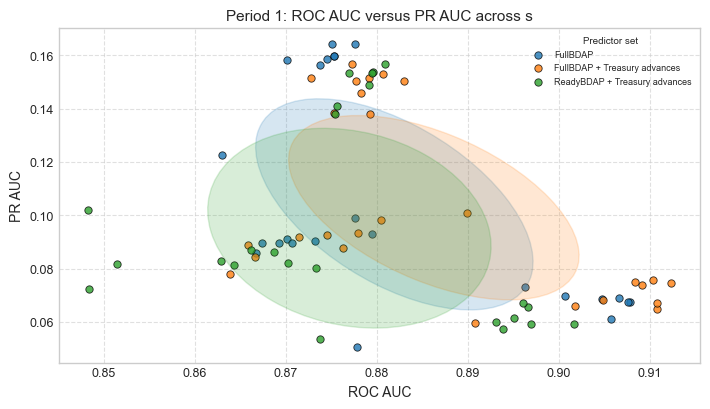

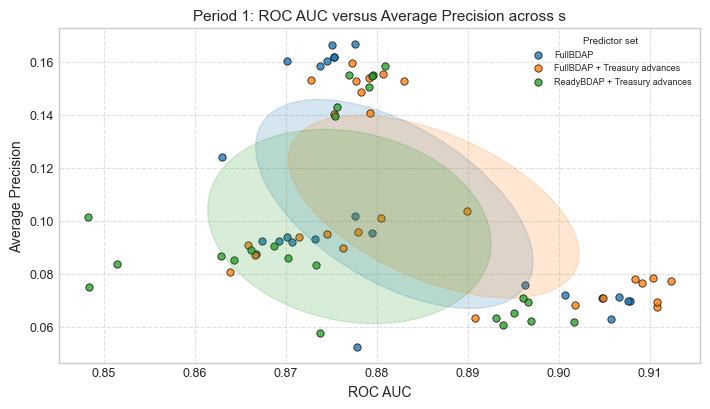

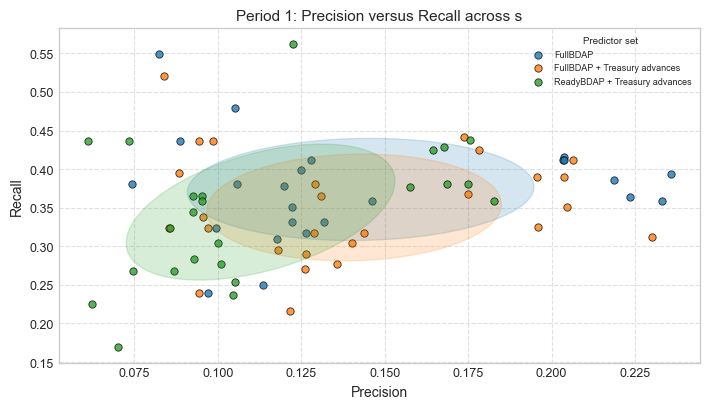

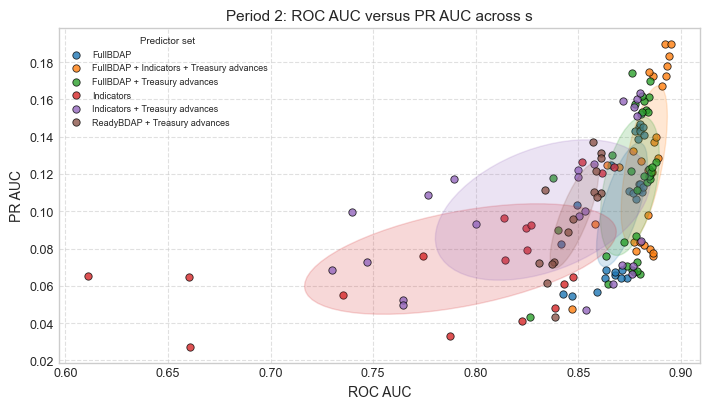

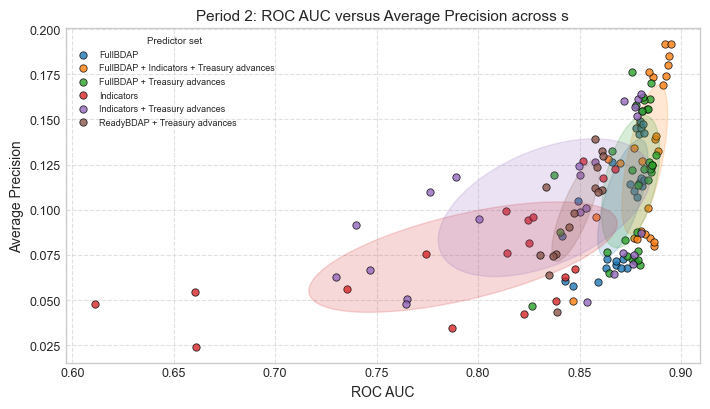

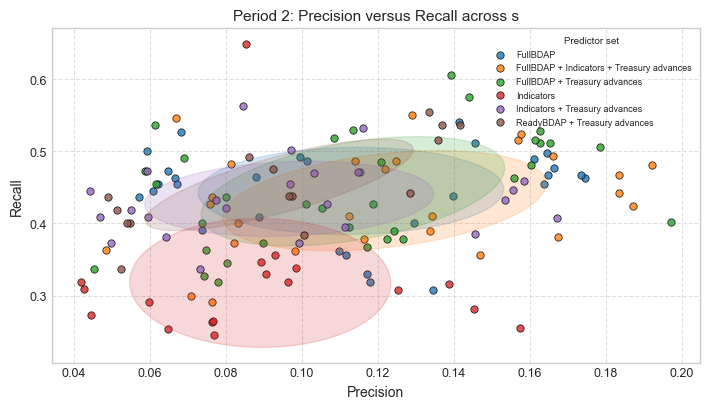

In [5]:
COLORS = list(plt.get_cmap("tab10").colors)

def add_confidence_ellipse(x, y, axis, color):
    if len(x) < 2:
        return
    covariance = np.cov(x, y)
    values, vectors = np.linalg.eigh(covariance)
    values = np.maximum(values, 0.0)
    order = values.argsort()[::-1]
    values, vectors = values[order], vectors[:, order]
    angle = np.degrees(np.arctan2(*vectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(values)
    axis.add_patch(Ellipse(
        (np.mean(x), np.mean(y)), width, height, angle=angle,
        edgecolor=color, facecolor=color, alpha=0.18,
    ))

def grouped_scatter(frame, x, y, group, legend_title, title, filename):
    values = sorted(frame[group].dropna().unique(), key=str)
    color_map = {value: COLORS[index % len(COLORS)] for index, value in enumerate(values)}
    figure, axis = plt.subplots(figsize=(7.2, 4.2))
    for value in values:
        block = frame.loc[frame[group] == value]
        color = color_map[value]
        axis.scatter(
            block[x], block[y], color=color, s=28, edgecolor="black",
            linewidth=0.6, alpha=0.8, label=value,
        )
        add_confidence_ellipse(block[x].to_numpy(), block[y].to_numpy(), axis, color)
    axis.set_xlabel(METRIC_LABELS.get(x, x.replace("_", " ").title()), fontsize=10)
    axis.set_ylabel(METRIC_LABELS.get(y, y.replace("_", " ").title()), fontsize=10)
    axis.set_title(title, fontsize=11)
    axis.tick_params(labelsize=9)
    axis.legend(title=legend_title, loc="best", fontsize=6.5, title_fontsize=7)
    axis.grid(True, linestyle="--", alpha=0.6)
    figure.tight_layout()
    finish_plot(figure, filename)

for period, period_metrics in candidate_metrics.groupby("period", sort=True):
    grouped_scatter(
        period_metrics, "roc_auc", "pr_auc_trapezoid", "dataset_label",
        "Predictor set", f"Period {period}: ROC AUC versus PR AUC across s",
        f"piht-period-{period}-roc-pr-auc.png",
    )
    grouped_scatter(
        period_metrics, "roc_auc", "average_precision", "dataset_label",
        "Predictor set", f"Period {period}: ROC AUC versus Average Precision across s",
        f"piht-period-{period}-roc-average-precision.png",
    )
    grouped_scatter(
        period_metrics, "precision", "recall", "dataset_label",
        "Predictor set", f"Period {period}: Precision versus Recall across s",
        f"piht-period-{period}-precision-recall.png",
    )

## Feature inclusion across horizons

Feature selections are aggregated across target horizons within each dataset setup, while P1 and P2 remain separate. The selection rate divides the count by the total number of fitted repetitions in that dataset setup, making groups with different numbers of configurations directly comparable. For the one-year input setup, the redundant `@t-0` suffix is removed from displayed feature names; the names stored in the result JSON files are unchanged.
With one seed per configuration, frequencies count inclusion across the three forecast horizons, not stability across repeated random splits.


Period 1 - FullBDAP - input 1 year(s) - target horizons [1, 2, 3] - 24 fitted models
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/p1_bdap_i1_feature_frequency.png
Period 1 - FullBDAP + Treasury advances - input 1 year(s) - target horizons [1, 2, 3] - 27 fitted models
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/p1_bdap_anticipazioni_i1_feature_frequency.png
Period 1 - ReadyBDAP + Treasury advances - input 1 year(s) - target horizons [1, 2, 3] - 24 fitted models
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/p1_readybdap_anticipazioni_i1_feature_frequency.png
Period 2 - FullBDAP - input 1 year(s) - target horizons [1, 2, 3] - 30 fitted models
Saved /Users/matteobergamaschi/Desktop/piht_classification_git/results/notebook_plots/p2_bdap_i1_feature_frequency.png
Period 2 - FullBDAP + Treasury advances - input 1 year(s) - target horizons [1, 2, 3] - 33 fitted models
Saved

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,1,bdap,FullBDAP,1,$P$,24,100%
1,1,bdap,FullBDAP,1,$S3_{P1}$ PAY PY,23,96%
2,1,bdap,FullBDAP,1,$Z5$,23,96%
3,1,bdap,FullBDAP,1,$Z4$,23,96%
4,1,bdap,FullBDAP,1,$S3_{P1}$ COM,22,92%
5,1,bdap,FullBDAP,1,$Z2$,21,88%
6,1,bdap,FullBDAP,1,$S1_{P1}$ PAY CY,20,83%
7,1,bdap,FullBDAP,1,$E6_{P1}$ COL CY,20,83%
8,1,bdap,FullBDAP,1,$S1_{P1}$ COM,19,79%
9,1,bdap,FullBDAP,1,$S4_{P1}$ PAY CY,17,71%


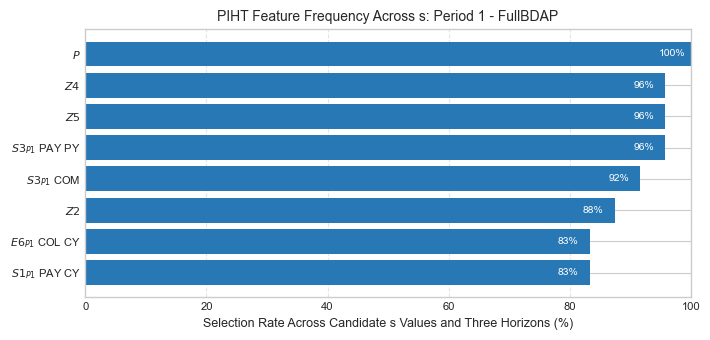

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$A4$,27,100%
1,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$P$,27,100%
2,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z5$,27,100%
3,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z4$,27,100%
4,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S1_{P1}$ PAY CY,24,89%
5,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z2$,22,81%
6,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S1_{P1}$ COM,22,81%
7,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S3_{P1}$ COM,22,81%
8,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S1_{P1}$ PAY PY,20,74%
9,1,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S3_{P1}$ PAY PY,20,74%


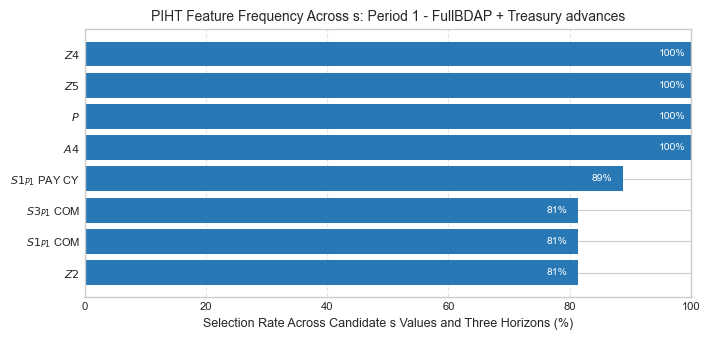

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$A4$,24,100%
1,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$P$,23,96%
2,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z4$,23,96%
3,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$S3_{P1}$ COM,20,83%
4,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z5$,20,83%
5,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$E4_{P1}$ REC,18,75%
6,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z2$,16,67%
7,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$S1_{P1}$ COM,15,62%
8,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z1$,14,58%
9,1,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$E6_{P1}$ REC,13,54%


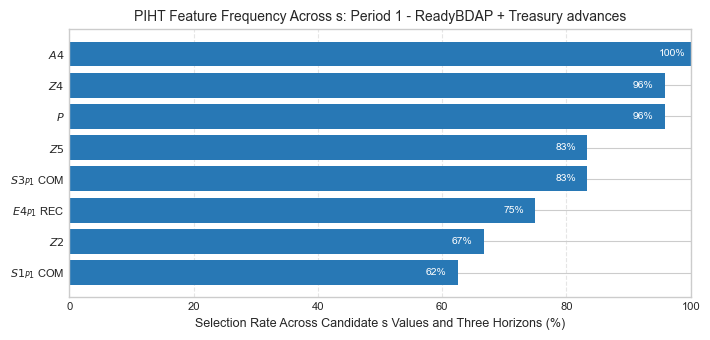

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,2,bdap,FullBDAP,1,$S3_{P2}$ PAY CY,29,97%
1,2,bdap,FullBDAP,1,$Z4$,28,93%
2,2,bdap,FullBDAP,1,$Z5$,27,90%
3,2,bdap,FullBDAP,1,$E3_{P2}$ COL CY,26,87%
4,2,bdap,FullBDAP,1,$Z1$,24,80%
5,2,bdap,FullBDAP,1,$Z2$,24,80%
6,2,bdap,FullBDAP,1,$E3_{P2}$ REC,24,80%
7,2,bdap,FullBDAP,1,$E7_{P2}$ COL PY,23,77%
8,2,bdap,FullBDAP,1,$S3_{P2}$ COM,22,73%
9,2,bdap,FullBDAP,1,$E8_{P2}$ COL PY,22,73%


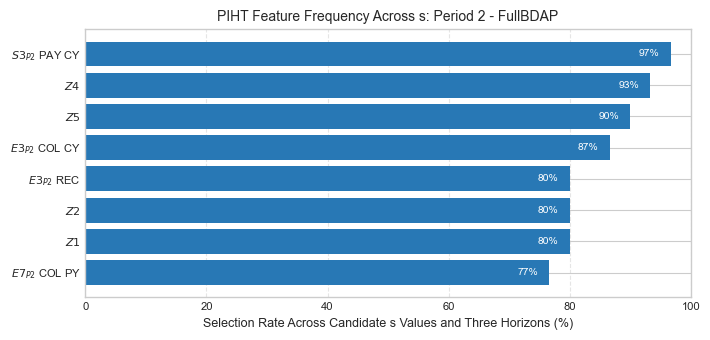

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$A4$,31,94%
1,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z4$,30,91%
2,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S3_{P2}$ PAY CY,29,88%
3,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z5$,29,88%
4,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z1$,27,82%
5,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$E3_{P2}$ REC,27,82%
6,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$E7_{P2}$ COL PY,26,79%
7,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$Z2$,26,79%
8,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$E3_{P2}$ COL CY,26,79%
9,2,bdap-anticipazioni,FullBDAP + Treasury advances,1,$S3_{P2}$ PAY PY,25,76%


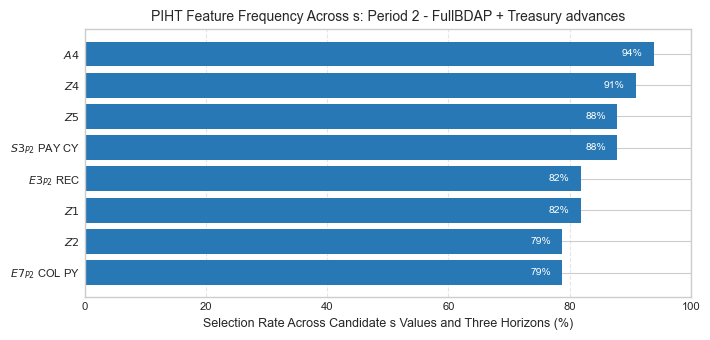

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$Z4$,26,96%
1,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$R5$,26,96%
2,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$A4$,25,93%
3,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$Z5$,24,89%
4,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$R10$,21,78%
5,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$E3_{P2}$ COL CY,20,74%
6,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$A3$,19,70%
7,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$S3_{P2}$ PAY CY,19,70%
8,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$Z1$,19,70%
9,2,bdap-indicatori-anticipazioni,FullBDAP + Indicators + Treasury advances,1,$A2$,18,67%


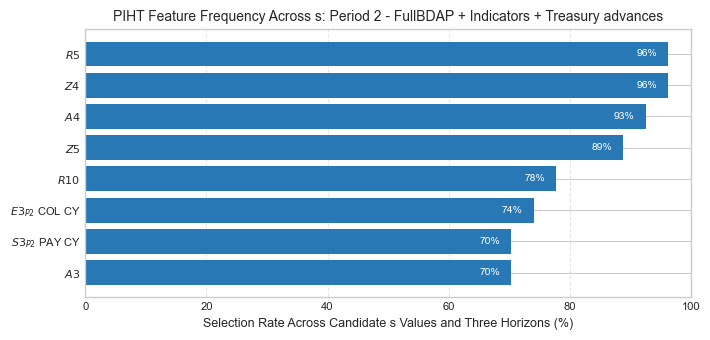

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,2,indicatori,Indicators,1,$R8$,17,94%
1,2,indicatori,Indicators,1,$R5$,15,83%
2,2,indicatori,Indicators,1,$R3$,11,61%
3,2,indicatori,Indicators,1,$R1$,9,50%
4,2,indicatori,Indicators,1,$R7$,8,44%
5,2,indicatori,Indicators,1,$R6$,6,33%
6,2,indicatori,Indicators,1,$R10$,6,33%
7,2,indicatori,Indicators,1,$R2$,5,28%
8,2,indicatori,Indicators,1,$R4$,5,28%
9,2,indicatori,Indicators,1,$R9$,5,28%


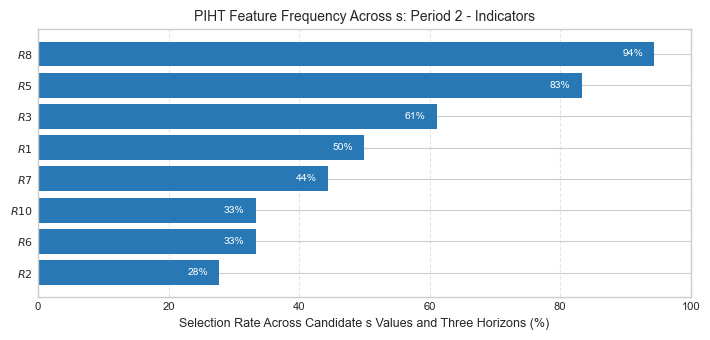

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$A4$,22,92%
1,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R3$,19,79%
2,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R5$,15,62%
3,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R1$,14,58%
4,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R10$,12,50%
5,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R4$,12,50%
6,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$A5$,11,46%
7,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$A2$,11,46%
8,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R7$,10,42%
9,2,indicatori-anticipazioni,Indicators + Treasury advances,1,$R6$,10,42%


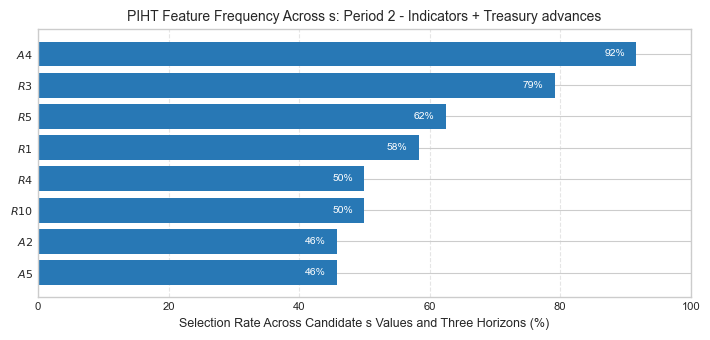

,period,dataset,dataset_label,input_depth,feature,times_selected,selection_rate
0,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$A4$,15,100%
1,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z5$,14,93%
2,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z4$,14,93%
3,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$S2_{P2}$ COM,14,93%
4,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$S3_{P2}$ COM,12,80%
5,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z1$,12,80%
6,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$P$,12,80%
7,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$Z2$,11,73%
8,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$E7_{P2}$ REC,11,73%
9,2,readybdap-anticipazioni,ReadyBDAP + Treasury advances,1,$A3$,9,60%


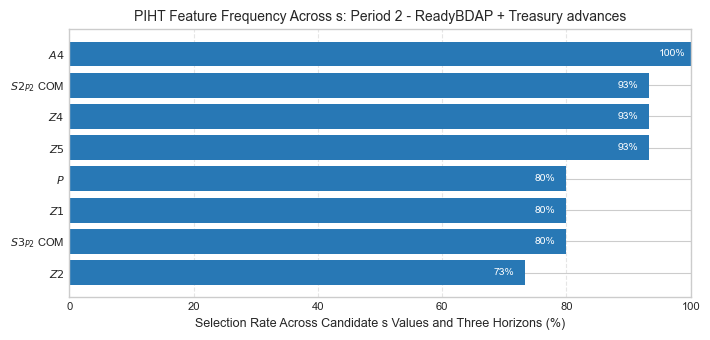

In [6]:
dataset_groups = {}
for result in results.values():
    metadata = result["dataset"]
    key = (metadata["period"], metadata["features"], metadata["input_depth"])
    dataset_groups.setdefault(key, []).append(result)

feature_rows = []
for (period, dataset, input_depth), group_results in sorted(dataset_groups.items()):
    label = DATASET_LABELS.get(dataset, dataset.replace("-", " + "))
    total_models = sum(
        len(repetition["k_selection"])
        for result in group_results
        for repetition in result["repetitions"]
    )
    target_depths = sorted(result["dataset"]["target_depth"] for result in group_results)
    counts = Counter(
        display_feature_name(feature, input_depth)
        for result in group_results
        for repetition in result["repetitions"]
        for candidate in repetition["k_selection"]
        for feature in candidate["selected_features"]
    )
    table = pd.DataFrame(counts.most_common(), columns=["feature", "times_selected"])
    table["selection_rate"] = table["times_selected"] / total_models
    table.insert(0, "input_depth", input_depth)
    table.insert(0, "dataset_label", label)
    table.insert(0, "dataset", dataset)
    table.insert(0, "period", period)
    feature_rows.append(table)

    top = table.head(TOP_FEATURES).sort_values("selection_rate")
    print(
        f"Period {period} - {label} - input {input_depth} year(s) - "
        f"target horizons {target_depths} - {total_models} fitted models"
    )
    display(table.head(25).style.format({"selection_rate": "{:.0%}"}))
    figure, axis = plt.subplots(figsize=(7.2, 3.5))
    labels = [textwrap.fill(name, width=38) for name in top["feature"]]
    percentages = 100 * top["selection_rate"]
    bars = axis.barh(labels, percentages, color="#2878B5")
    axis.set_xlim(0, 100)
    axis.set_xlabel("Selection Rate Across Candidate s Values and Three Horizons (%)", fontsize=9)
    axis.set_title(f"PIHT Feature Frequency Across s: Period {period} - {label}", fontsize=10)
    axis.tick_params(axis="x", labelsize=8)
    axis.tick_params(axis="y", labelsize=8)
    axis.bar_label(bars, labels=[f"{value:.0f}%" for value in percentages], padding=-23, color="white", fontsize=7.5)
    axis.grid(True, axis="x", linestyle="--", alpha=0.5)
    figure.tight_layout()
    dataset_slug = dataset.replace("-", "_")
    finish_plot(
        figure, f"p{period}_{dataset_slug}_i{input_depth}_feature_frequency.png"
    )
feature_frequency = pd.concat(feature_rows, ignore_index=True)

## Runtime

Runtime is reported separately for every period, dataset setup, input depth, and target depth. It includes all fits over that configuration's own candidate `K` grid.

In [7]:
runtime = {}
for period, period_metrics in metrics.groupby("period", sort=True):
    table = (
        period_metrics.groupby(
            ["dataset_label", "input_depth", "target_depth"]
        )[["repetition_seconds", "piht_grid_fit_seconds"]]
        .agg(["count", "median", "mean", "std", "min", "max"])
        .round(3)
    )
    runtime[period] = table
    print(f"Period {period} runtime")
    display(table)

Period 1 runtime
Period 2 runtime


repetition_seconds  \
                                                                    count   
dataset_label                 input_depth target_depth                      
FullBDAP                      1           1                             1   
                                          2                             1   
                                          3                             1   
FullBDAP + Treasury advances  1           1                             1   
                                          2                             1   
                                          3                             1   
ReadyBDAP + Treasury advances 1           1                             1   
                                          2                             1   
                                          3                             1   

                                                                              \
                                                         median     mean std   
dataset_label                 input_depth target_depth                         
FullBDAP                      1           1              94.143   94.143 NaN   
                                          2              65.060   65.060 NaN   
                                          3             100.769  100.769 NaN   
FullBDAP + Treasury advances  1           1              41.714   41.714 NaN   
                                          2              82.301   82.301 NaN   
                                          3              80.670   80.670 NaN   
ReadyBDAP + Treasury advances 1           1              23.569   23.569 NaN   
                                          2              26.538   26.538 NaN   
                                          3              26.269   26.269 NaN   

                                                                          \
                                                            min      max   
dataset_label                 input_depth target_depth                     
FullBDAP                      1           1              94.143   94.143   
                                          2              65.060   65.060   
                                          3             100.769  100.769   
FullBDAP + Treasury advances  1           1              41.714   41.714   
                                          2              82.301   82.301   
                                          3              80.670   80.670   
ReadyBDAP + Treasury advances 1           1              23.569   23.569   
                                          2              26.538   26.538   
                                          3              26.269   26.269   

                                                       piht_grid_fit_seconds  \
                                                                       count   
dataset_label                 input_depth target_depth                         
FullBDAP                      1           1                                1   
                                          2                                1   
                                          3                                1   
FullBDAP + Treasury advances  1           1                                1   
                                          2                                1   
                                          3                                1   
ReadyBDAP + Treasury advances 1           1                                1   
                                          2                                1   
                                          3                                1   

                                                                            \
                                                        median    mean std   
dataset_label                 input_depth target_depth                       
FullBDAP                      1           1             92.53

repetition_seconds  \
                                                                                count   
dataset_label                             input_depth target_depth                      
FullBDAP                                  1           1                             1   
                                                      2                             1   
                                                      3                             1   
FullBDAP + Indicators + Treasury advances 1           1                             1   
                                                      2                             1   
                                                      3                             1   
FullBDAP + Treasury advances              1           1                             1   
                                                      2                             1   
                                                      3                             1   
Indicators                                1           1                             1   
                                                      2                             1   
                                                      3                             1   
Indicators + Treasury advances            1           1                             1   
                                                      2                             1   
                                                      3                             1   
ReadyBDAP + Treasury advances             1           1                             1   
                                                      2                             1   
                                                      3                             1   

                                                                            \
                                                                    median   
dataset_label                             input_depth target_depth           
FullBDAP                                  1           1             52.903   
                                                      2             50.417   
                                                      3             47.366   
FullBDAP + Indicators + Treasury advances 1           1             84.370   
                                                      2             84.061   
                                                      3             74.826   
FullBDAP + Treasury advances              1           1             69.102   
                                                      2             70.726   
                                                      3             65.681   
Indicators                                1           1             17.110   
                                                      2             13.891   
                                                      3             10.356   
Indicators + Treasury advances            1           1             22.478   
                                                      2             21.283   
                                                      3             16.664   
ReadyBDAP + Treasury advances             1           1             20.523   
                                                      2             18.528   
                                                      3             15.779   

                                                                            \
                                                                      mean   
dataset_label                             input_depth target_depth           
FullBDAP                                  1           1             52.903   
                                                      2             50.417   
                                                      3             47.366   
FullBDAP + Indicators + Treasury advances 1           1             84.370   
            